In [4]:
from google.colab import drive
import os

# Remove the old mount folder if Colab created a broken local folder
!rm -rf /content/drive

# Mount Google Drive again
drive.mount("/content/drive")

print(os.path.exists("/content/drive/MyDrive"))
print(os.listdir("/content/drive/MyDrive")[:20])

Mounted at /content/drive
True
['Getting started.pdf', 'Application-SSA202370050584.pdf', 'INTER.pdf', ' car loan.pdf', 'pancard.pdf', 'B.Com(Computers) 1&2 Semester Revised Syllabus for 2019-20.pdf', '8375612-XXXXXXX-500019.pdf', 'IXIBS1880855450_Ticket.pdf', 'RDBMS #LAB#Queries (1).gdoc', 'SQL LAB KEY1 (1).gdoc', 'RDBMS #LAB#Queries.gdoc', 'SQL LAB KEY1.gdoc', 'MotorClaimform (2).pdf', 'march kotak.pdf', ' Jan Kotak .pdf', ' Dec Kotak .pdf', ' Feb kotak.pdf', 'thumb navy.jpg', 'signature navy.jpg', 'dad sign.jpg']


In [5]:
import os

PROJECT_PATH = "/content/drive/MyDrive/Store-Sales-Forecasting"
PROCESSED_PATH = f"{PROJECT_PATH}/Data/Processed"

print("Project exists:", os.path.exists(PROJECT_PATH))
print("Processed folder exists:", os.path.exists(PROCESSED_PATH))
print("Files:", os.listdir(PROCESSED_PATH))

Project exists: True
Processed folder exists: True
Files: ['master_dataset.csv', 'model_ready_dataset.csv', 'model_results.csv', 'xgboost_predictions.csv', 'model_results_light.csv', 'xgboost_predictions_light.csv']


In [6]:
import pandas as pd

evaluation_df = pd.read_csv(
    f"{PROCESSED_PATH}/xgboost_predictions_light.csv",
    parse_dates=["date"]
)

print(evaluation_df.shape)
evaluation_df.head()

(50000, 3)


,date,actual_sales,predicted_sales
0,2017-06-16,383.047,365.833620
1,2017-08-08,72.000,107.152050
2,2017-07-24,0.000,0.803550
3,2017-05-25,68.000,68.728836
4,2017-06-13,818.000,757.519700


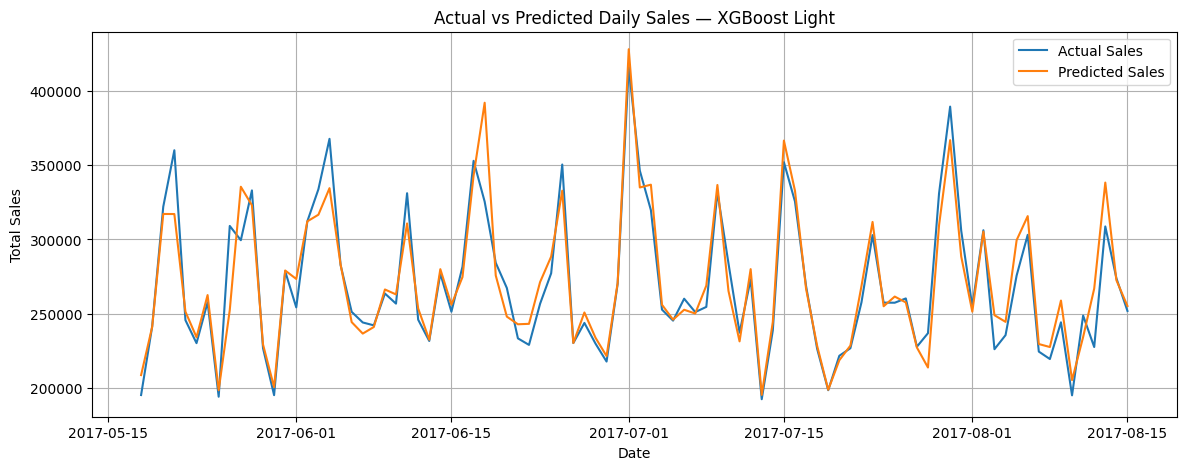

In [7]:
import matplotlib.pyplot as plt
import os

IMAGES_PATH = "/content/drive/MyDrive/Store-Sales-Forecasting/Images"
os.makedirs(IMAGES_PATH, exist_ok=True)

# Sum sampled records by date for a readable daily comparison
daily_evaluation = (
    evaluation_df.groupby("date", as_index=False)
    .agg(
        actual_sales=("actual_sales", "sum"),
        predicted_sales=("predicted_sales", "sum")
    )
)

plt.figure(figsize=(14, 5))
plt.plot(
    daily_evaluation["date"],
    daily_evaluation["actual_sales"],
    label="Actual Sales"
)
plt.plot(
    daily_evaluation["date"],
    daily_evaluation["predicted_sales"],
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Daily Sales — XGBoost Light")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)

plt.savefig(
    f"{IMAGES_PATH}/actual_vs_predicted_xgboost_light.png",
    bbox_inches="tight"
)
plt.show()

### Observation
The predicted daily sales generally follow the actual sales trend. Differences between the lines represent prediction errors, especially on unusual high-demand or low-demand days.

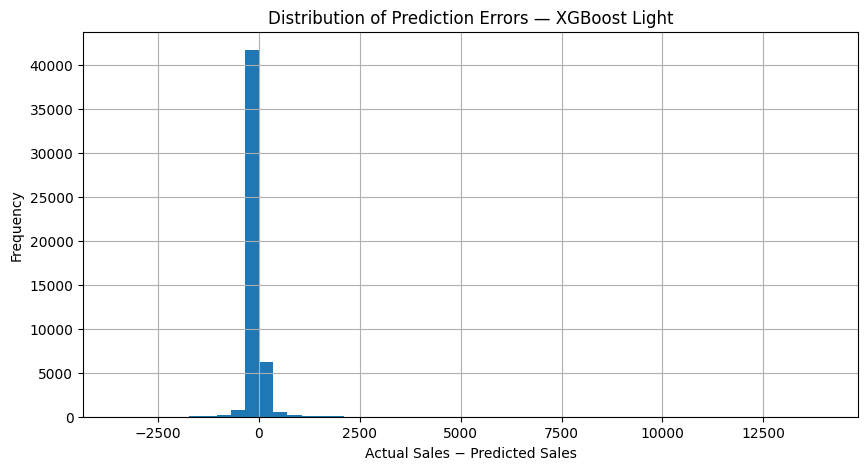

In [8]:
evaluation_df["error"] = (
    evaluation_df["actual_sales"] - evaluation_df["predicted_sales"]
)

plt.figure(figsize=(10, 5))
plt.hist(evaluation_df["error"], bins=50)
plt.title("Distribution of Prediction Errors — XGBoost Light")
plt.xlabel("Actual Sales − Predicted Sales")
plt.ylabel("Frequency")
plt.grid(True)

plt.savefig(
    f"{IMAGES_PATH}/prediction_error_distribution.png",
    bbox_inches="tight"
)
plt.show()

### Observation
Most prediction errors are concentrated around zero, meaning the model usually predicts sales close to the actual value. A small number of large positive errors remain, indicating that unusually high sales are sometimes underpredicted.

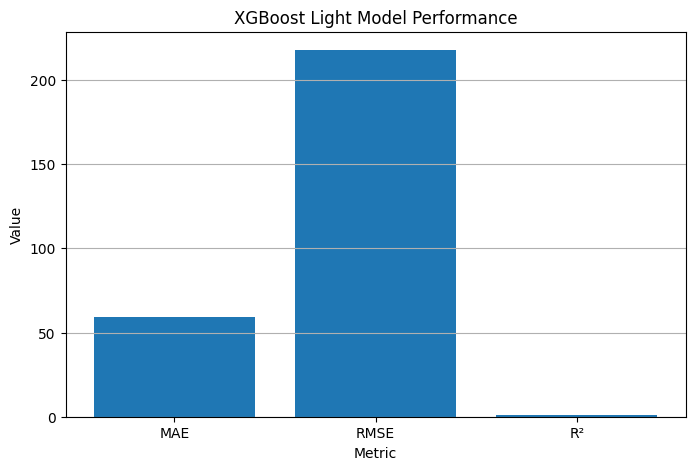

,Metric,Value
0,MAE,59.3500
1,RMSE,217.7500
2,R²,0.9732


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

comparison_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [59.35, 217.75, 0.9732]
})

plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Metric"], comparison_df["Value"])

plt.title("XGBoost Light Model Performance")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.grid(axis="y")

plt.savefig(
    f"{IMAGES_PATH}/xgboost_light_model_performance.png",
    bbox_inches="tight"
)
plt.show()

comparison_df

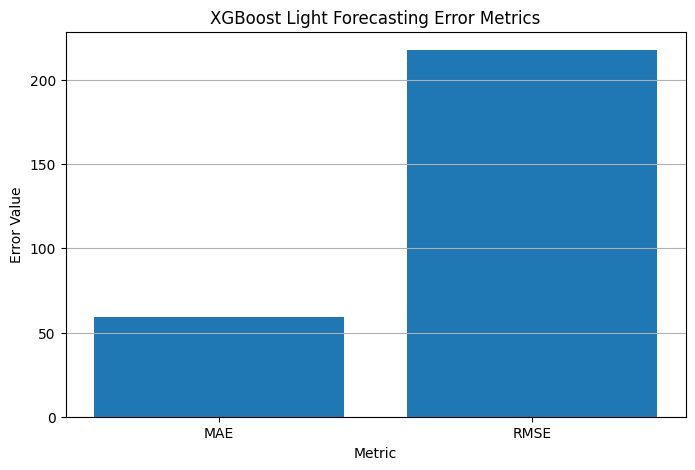

In [10]:
error_metrics_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE"],
    "Value": [59.35, 217.75]
})

plt.figure(figsize=(8, 5))
plt.bar(error_metrics_df["Metric"], error_metrics_df["Value"])

plt.title("XGBoost Light Forecasting Error Metrics")
plt.xlabel("Metric")
plt.ylabel("Error Value")
plt.grid(axis="y")

plt.savefig(
    f"{IMAGES_PATH}/xgboost_light_error_metrics.png",
    bbox_inches="tight"
)
plt.show()

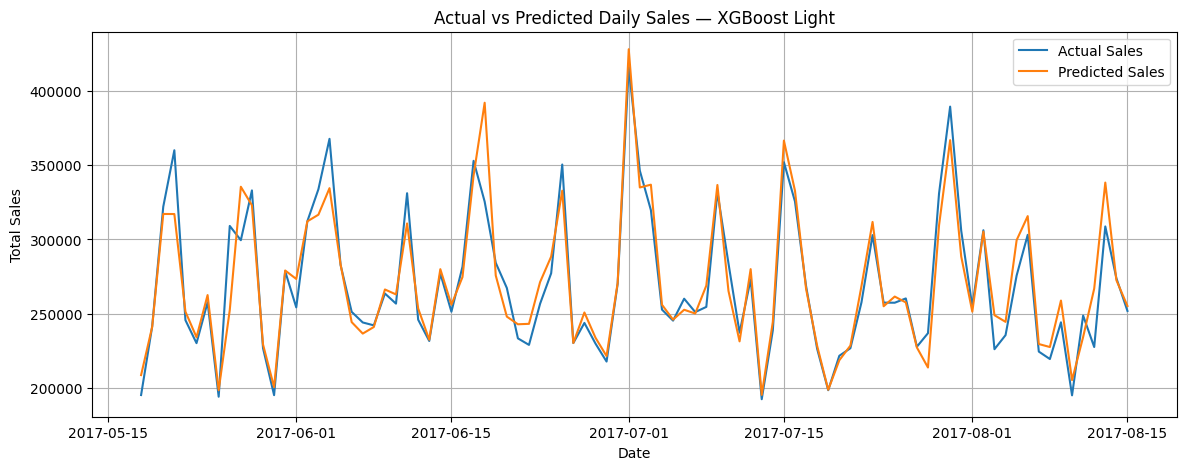

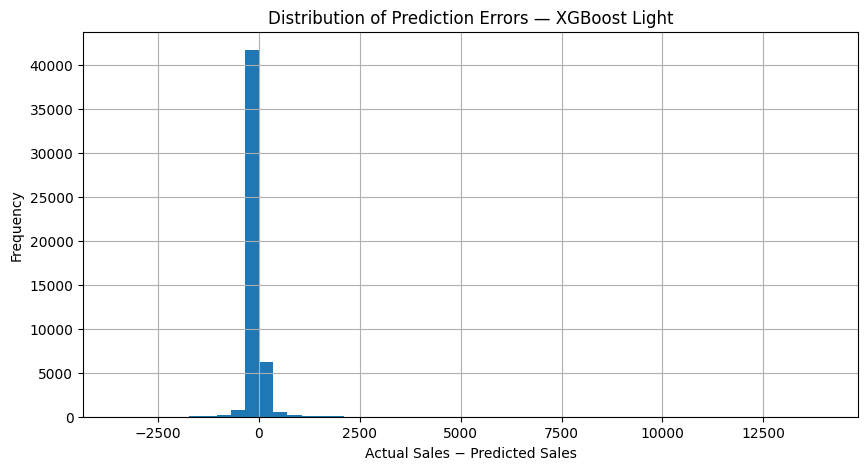

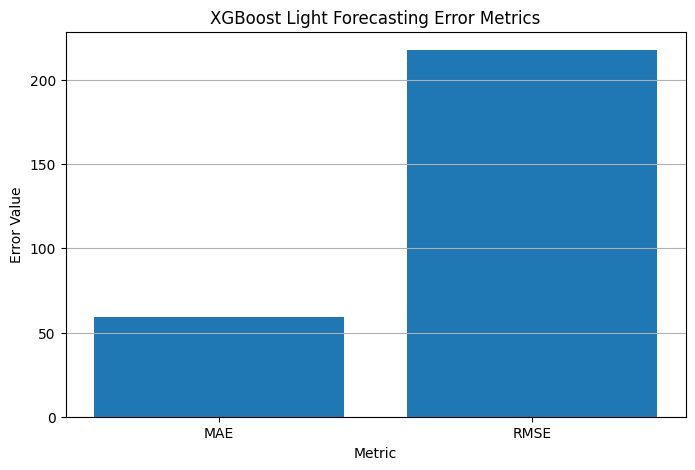

All graphs saved successfully.
['daily_sales_trend.png', 'monthly_sales_trend.png', 'top_10_stores_sales.png', 'top_10_product_families.png', 'promotion_vs_sales.png', 'holiday_vs_normal_sales.png', 'average_sales_by_day_of_week.png', 'transactions_vs_sales.png', 'actual_vs_predicted_xgboost_light.png', 'prediction_error_distribution.png', 'xgboost_light_model_performance.png', 'xgboost_light_error_metrics.png']


In [11]:
import os
import matplotlib.pyplot as plt
import pandas as pd

IMAGES_PATH = "/content/drive/MyDrive/Store-Sales-Forecasting/Images"
os.makedirs(IMAGES_PATH, exist_ok=True)

# 1. Actual vs Predicted Daily Sales
daily_evaluation = (
    evaluation_df.groupby("date", as_index=False)
    .agg(
        actual_sales=("actual_sales", "sum"),
        predicted_sales=("predicted_sales", "sum")
    )
)

plt.figure(figsize=(14, 5))
plt.plot(daily_evaluation["date"], daily_evaluation["actual_sales"], label="Actual Sales")
plt.plot(daily_evaluation["date"], daily_evaluation["predicted_sales"], label="Predicted Sales")
plt.title("Actual vs Predicted Daily Sales — XGBoost Light")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)
plt.savefig(f"{IMAGES_PATH}/actual_vs_predicted_xgboost_light.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close()

# 2. Prediction Error Distribution
evaluation_df["error"] = (
    evaluation_df["actual_sales"] - evaluation_df["predicted_sales"]
)

plt.figure(figsize=(10, 5))
plt.hist(evaluation_df["error"], bins=50)
plt.title("Distribution of Prediction Errors — XGBoost Light")
plt.xlabel("Actual Sales − Predicted Sales")
plt.ylabel("Frequency")
plt.grid(True)
plt.savefig(f"{IMAGES_PATH}/prediction_error_distribution.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close()

# 3. MAE and RMSE chart
error_metrics_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE"],
    "Value": [59.35, 217.75]
})

plt.figure(figsize=(8, 5))
plt.bar(error_metrics_df["Metric"], error_metrics_df["Value"])
plt.title("XGBoost Light Forecasting Error Metrics")
plt.xlabel("Metric")
plt.ylabel("Error Value")
plt.grid(axis="y")
plt.savefig(f"{IMAGES_PATH}/xgboost_light_error_metrics.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close()

print("All graphs saved successfully.")
print(os.listdir(IMAGES_PATH))